<a href="https://colab.research.google.com/github/rahmani3101/Data-Science/blob/main/PCA_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Principal Component Analysis (PCA) on Iris Dataset

This section performs PCA on the Iris dataset to reduce its dimensionality to two principal components. The features are standardized before applying PCA, and the results are visualized.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_df = pd.read_csv(url, names=column_names)

print("First 5 rows of the Iris dataset:")
display(iris_df.head())

First 5 rows of the Iris dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Separate features (X) and target (y)
X = iris_df.drop('species', axis=1)
y = iris_df['species']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of scaled features:", X_scaled.shape)

Shape of scaled features: (150, 4)


### Apply Principal Component Analysis (PCA)

Now, we apply PCA to reduce the dimensionality of the standardized data to two principal components.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with the principal components and species for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])
pca_df['species'] = y

print("First 5 rows of PCA transformed data:")
display(pca_df.head())

First 5 rows of PCA transformed data:


,principal_component_1,principal_component_2,species
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


In [ ]:
print(f"Explained variance ratio of PC1: {pca.explained_variance_ratio_[0]:.2f}")
print(f"Explained variance ratio of PC2: {pca.explained_variance_ratio_[1]:.2f}")
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2f}")

Explained variance ratio of PC1: 0.73
Explained variance ratio of PC2: 0.23
Total explained variance by 2 components: 0.96


### Visualize Principal Components

We will now plot the data using the first two principal components, coloring the points by their respective species. This visualization helps us understand how well these components separate the different classes.

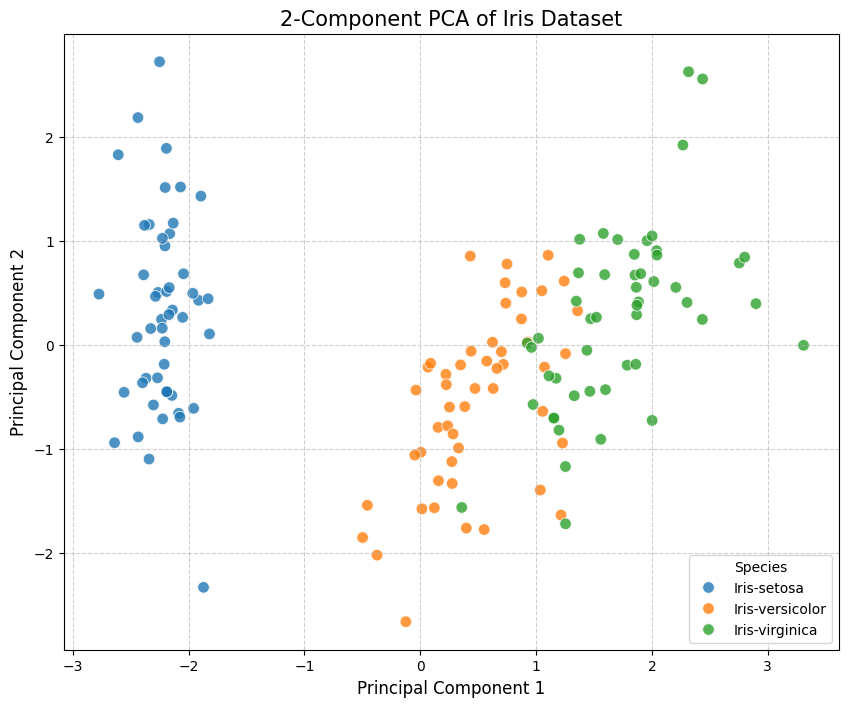

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='species',
    data=pca_df,
    s=70, # size of the points
    alpha=0.8 # transparency
)
plt.title('2-Component PCA of Iris Dataset', fontsize=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Species')
plt.show()